# Homework: Build a StationXML Inventory for recent KSC deployment

Seven USF stations were deployed at Kennedy Space Center between January 7-12, 2026.
* Each features a Nanometrics Centaur digitizer, and a Nanometrics Trillium Compact Post-Hole 120-s seismometer.
* This is the same equipment we setup in our class a few weeks ago - except we also had infrasound.

Three additional seismic stations were setup by Marshall Space Flight Center, using Guralp and Silicon Audio equipment. You can ignore those for this exercise - or potentially earn some bonus points if you find responses for those too!

## Goal
Create a valid **StationXML** file for this small network using:
- Station coordinates stored in an **Excel** file
- Instrument responses pulled from the **IRIS Nominal Response Library (NRL)**

You will:
1. Load the station list with **pandas** into a pandas DataFrame
2. Create a Response object for a USF Nanometrics station
3. Build an ObsPy **Inventory**
4. Write out a **StationXML** file

> We're keeping it simple: one network, three channels per station (Z, N, E), same equipment at each site.

**Warning:** only attempt this homework after you have completed this week's reading exercises (notebooks 73 and 74)

## Provided file
Your station list is in:

- `Summary_Seismic_Station_List.xlsx`

One column contains photos — **ignore it**.

An alternative version of the Excel file is also provided as a Comma-Separated-Variable (CSV) text file, just in case you cannot read the Excel file. This is easier to read.

(If you open any Excel file with Excel, you can save it as a CSV).

## Make sure you have openpyxl installed in your conda environment!
This is required to read Excel files. CSV files will work without it.

In [1]:
import sys
!conda install -y openpyxl --prefix {sys.prefix}

Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.



## Minimal pandas intro (what you need today)

**pandas** is a Python library for working with tables (“dataframes”).  
For this homework you only need to:
- read an Excel file
- select a few columns
- loop over rows

**Note**: you may need to install openpyxl in conda, and then restart this notebook/kernel. At the command line:

```
conda activate compsci # or whatever your conda env is
conda install openpyxml
```

In [2]:
import pandas as pd

xlsx_path = r"Summary_Seismic_Station_List.xlsx"
df = pd.read_excel(xlsx_path)

df.head(10)

,Site Name,GPS Coordinates,Photo,lat,lon,Notes,Digitizer,Seismometer,Infrasound
0,B01,"28°37'17""N 80°36'24""W",NaN,28.621389,-80.606667,Seismic (nanometrics) #271. Infrasound (other)...,Centaur (271),NaN,"infraBSU (268, 412, 453)"
1,B03,"28°38'34""N 80°37'25""W",NaN,28.642778,-80.623611,Sensor ~100ft from Eagle 4 tower on dune. Seis...,NaN,Trillium C-PH120 (2663),infraBSU (417)
2,B05,"28°38'24""N 80°38'42""W",NaN,28.640000,-80.645000,Sensor in front of Helipad 9 sign. Seismic (na...,Centaur (386),Trillium C-PH120 (2392),infraBSU (414)
3,B07,"28°36'26""N 80°35'39""W",NaN,28.607222,-80.594167,Sensor (Guralp) #00B68. IPv4 169.254.168.11,Certimus (00B68),NaN,NaN
4,B12,"28°37'18""N 80°38'50""W",NaN,28.621667,-80.647222,Sensor located off Happy Creek Rd. Guralp Cert...,Certimus (00D68),NaN,NaN
5,B14,"28°37'56""N 80°36'57""W",NaN,28.632222,-80.615833,Seismic (nanometrics) #2719. Infrasound x3 - #...,Centaur (383),Trillium C-PH120 (2719),"infraBSU (292, 461, 336)"
6,B20,"28°34'25""N 80°34'20""W",NaN,28.573611,-80.572222,Sensor located 20 ft 195degrees from north. Se...,Centaur (384),NaN,"M25 (071975), infraBSU (403)"
7,B23,"28°34'43""N 80°36'28""W",NaN,28.578611,-80.607778,Sensor (gain set to 5 Vpp). SA #the only one w...,NaN,Silicon Audio,NaN
8,B24,"28°34'50""N 80°38'27""W",NaN,28.580556,-80.640833,Seismic (nanometrics) #2619. Infrasound #0224....,Centaur (166),Trillium C-PH120 (2619),infraBSU (224)
9,B29,"28°37'05""N 80°40'37""W",NaN,28.618056,-80.676944,Site of controlled burn. Station watered to sa...,Centaur (202),Trillium C-PH120 (2410),infraBSU (436)


If for any reason you cannot load the Excel file, you can try the CSV file instead:
```
df = pd.read_csv("Summary_Seismic_Station_List.csv")
```

In [3]:
df.columns

Index(['Site Name', 'GPS Coordinates', 'Photo', 'lat', 'lon', 'Notes',
       'Digitizer', 'Seismometer', 'Infrasound'],
      dtype='object')

## Step 1 — Keep only the columns we need

For StationXML, we need at minimum:
- station code (name)
- latitude
- longitude

We will also keep:
- seismometer model (if present)
- digitizer model (if present)

In [4]:
use_cols = ["Site Name", "lat", "lon", "Seismometer", "Digitizer"]
stations = df[use_cols].copy()

# Ignore the Photo column (already excluded)
stations

,Site Name,lat,lon,Seismometer,Digitizer
0,B01,28.621389,-80.606667,NaN,Centaur (271)
1,B03,28.642778,-80.623611,Trillium C-PH120 (2663),NaN
2,B05,28.640000,-80.645000,Trillium C-PH120 (2392),Centaur (386)
3,B07,28.607222,-80.594167,NaN,Certimus (00B68)
4,B12,28.621667,-80.647222,NaN,Certimus (00D68)
5,B14,28.632222,-80.615833,Trillium C-PH120 (2719),Centaur (383)
6,B20,28.573611,-80.572222,NaN,Centaur (384)
7,B23,28.578611,-80.607778,Silicon Audio,NaN
8,B24,28.580556,-80.640833,Trillium C-PH120 (2619),Centaur (166)
9,B29,28.618056,-80.676944,Trillium C-PH120 (2410),Centaur (202)


## Step 2 — Create a Response object for a USF Nanometrics station

In [5]:
# Model answer: create a Response object for the USF Nanometrics stations

from obspy.clients.nrl import NRL

nrl = NRL()

FS = 500 # added after reading ahead to Step 3

# USF equipment used at the seven USF stations
sensor_keys = [
    "Nanometrics",
    "Trillium Compact 120 (Vault, Posthole, OBS)",
    "754 V/m/s",
]

datalogger_keys = [
    "Nanometrics",
    "Centaur",
    "40 Vpp (1)",
    "Off",
    "Linear phase",
    str(FS)
]

resp_usf = nrl.get_response(
    sensor_keys=sensor_keys,
    datalogger_keys=datalogger_keys,
)

resp_usf


/var/folders/y1/0ksm02_j05q2mdjsdf6j7xj80000gp/T/ipykernel_39628/566006947.py:5: ObsPyDeprecationWarning: 
        DEPRECATED

        Direct access to online NRL is deprecated as it will stop working when
        the original NRLv1 gets taken offline (Spring 2023), please consider
        working locally with a downloaded full copy of the old NRLv1 or new
        NRLv2 following instructions on the
        `NRL landing page <https://ds.iris.edu/ds/nrl/>`_.
        
  nrl = NRL()


Channel Response
	From M/S (Velocity in Meters per Second) to COUNTS (Digital Counts)
	Overall Sensitivity: 3.0172e+08 defined at 1.000 Hz
	6 stages:
		Stage 1: PolesZerosResponseStage from M/S to V, gain: 754.3
		Stage 2: PolesZerosResponseStage from V to V, gain: 1
		Stage 3: CoefficientsTypeResponseStage from V to COUNTS, gain: 400000
		Stage 4: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1
		Stage 5: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1
		Stage 6: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1

## Step 3 - Create an ObsPy Inventory

The Inventory object should contain a list of 1 Network object.

The Network object should have a network code, description, and start_date, and contain a list of 7 Station objects.

Each Station object should have a station code, description, and coordinates, and a list of 3 Channel objects.

Each Channel object should have a channel code, a location code, coordinates (StationXML repeats them), depth, and sampling rate, and a Response object.


In [6]:
# Model answer: build an ObsPy Inventory for the seven USF stations

from obspy.core.inventory import Inventory, Network, Station, Channel, Site
from obspy import UTCDateTime

# -----------------------------
# Network-level metadata
# -----------------------------
NETWORK_CODE = "1R"
NETWORK_DESCRIPTION = "KSC Seismic Network"
START_DATE = UTCDateTime(2026, 1, 7)

# -----------------------------
# Channel metadata
# -----------------------------
CHANNEL_CODES = ["DHZ", "DHN", "DHE"]
LOC_CODE = ""
ELEV_M = 0.0
DEPTH_M = 0.75

def is_usf_station(row):
    seismometer = str(row["Seismometer"]) if not pd.isna(row["Seismometer"]) else ""
    digitizer = str(row["Digitizer"]) if not pd.isna(row["Digitizer"]) else ""

    return ("Trillium" in seismometer) or ("Centaur" in digitizer)

stations_usf = stations[stations.apply(is_usf_station, axis=1)].copy()
stations_usf


,Site Name,lat,lon,Seismometer,Digitizer
0,B01,28.621389,-80.606667,NaN,Centaur (271)
1,B03,28.642778,-80.623611,Trillium C-PH120 (2663),NaN
2,B05,28.640000,-80.645000,Trillium C-PH120 (2392),Centaur (386)
5,B14,28.632222,-80.615833,Trillium C-PH120 (2719),Centaur (383)
6,B20,28.573611,-80.572222,NaN,Centaur (384)
8,B24,28.580556,-80.640833,Trillium C-PH120 (2619),Centaur (166)
9,B29,28.618056,-80.676944,Trillium C-PH120 (2410),Centaur (202)


## Step 4 — Build Inventory, plot, and write StationXML

Inventory created at 2026-03-18T16:33:18.142694Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: KSC Seismic Network
	Contains:
		Networks (1):
			1R
		Stations (7):
			1R.B01 (B01)
			1R.B03 (B03)
			1R.B05 (B05)
			1R.B14 (B14)
			1R.B20 (B20)
			1R.B24 (B24)
			1R.B29 (B29)
		Channels (21):
			1R.B01..DHZ, 1R.B01..DHN, 1R.B01..DHE, 1R.B03..DHZ, 1R.B03..DHN, 
			1R.B03..DHE, 1R.B05..DHZ, 1R.B05..DHN, 1R.B05..DHE, 1R.B14..DHZ, 
			1R.B14..DHN, 1R.B14..DHE, 1R.B20..DHZ, 1R.B20..DHN, 1R.B20..DHE, 
			1R.B24..DHZ, 1R.B24..DHN, 1R.B24..DHE, 1R.B29..DHZ, 1R.B29..DHN, 
			1R.B29..DHE


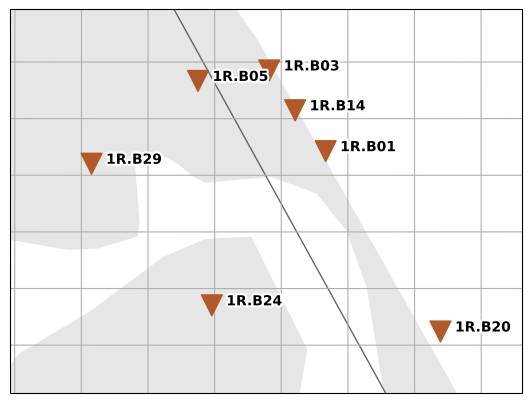

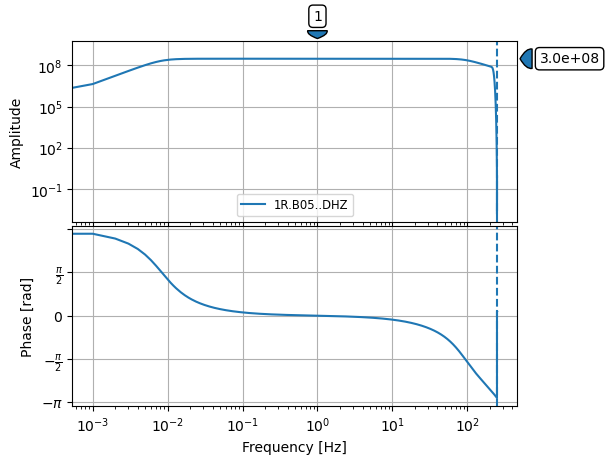

In [7]:
# Model answer: create stations/channels, build inventory, plot, and write StationXML

stations_list = []

for _, row in stations_usf.iterrows():
    sta_code = row["Site Name"]
    sta_lat = float(row["lat"])
    sta_lon = float(row["lon"])

    channels = []
    for chan_code in CHANNEL_CODES:
        if chan_code.endswith("Z"):
            azimuth = 0.0
            dip = -90.0
        elif chan_code.endswith("N"):
            azimuth = 0.0
            dip = 0.0
        else:  # E
            azimuth = 90.0
            dip = 0.0

        ch = Channel(
            code=chan_code,
            location_code=LOC_CODE,
            latitude=sta_lat,
            longitude=sta_lon,
            elevation=ELEV_M,
            depth=DEPTH_M,
            azimuth=azimuth,
            dip=dip,
            sample_rate=FS,
            response=resp_usf,
        )
        channels.append(ch)

    sta = Station(
        code=sta_code,
        latitude=sta_lat,
        longitude=sta_lon,
        elevation=ELEV_M,
        creation_date=START_DATE,
        site=Site(name=sta_code),
        channels=channels,
    )
    stations_list.append(sta)

network = Network(
    code=NETWORK_CODE,
    description=NETWORK_DESCRIPTION,
    start_date=START_DATE,
    stations=stations_list,
)

inventory = Inventory(
    networks=[network],
    source="KSC Seismic Network",
)

print(inventory)

inventory.plot(projection="local", level="channel")
inventory.plot_response(min_freq=0.001, output="VEL", station="B05", channel="DHZ")

out_xml = "ksc_usf_inventory.xml"
inventory.write(out_xml, format="STATIONXML")


## Step 5 — Quick check: read back the StationXML

In [8]:
from obspy import read_inventory

inv2 = read_inventory(out_xml)
print(inv2)

Inventory created at 2026-03-18T16:33:18.142694Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: KSC Seismic Network
	Contains:
		Networks (1):
			1R
		Stations (7):
			1R.B01 (B01)
			1R.B03 (B03)
			1R.B05 (B05)
			1R.B14 (B14)
			1R.B20 (B20)
			1R.B24 (B24)
			1R.B29 (B29)
		Channels (21):
			1R.B01..DHZ, 1R.B01..DHN, 1R.B01..DHE, 1R.B03..DHZ, 1R.B03..DHN, 
			1R.B03..DHE, 1R.B05..DHZ, 1R.B05..DHN, 1R.B05..DHE, 1R.B14..DHZ, 
			1R.B14..DHN, 1R.B14..DHE, 1R.B20..DHZ, 1R.B20..DHN, 1R.B20..DHE, 
			1R.B24..DHZ, 1R.B24..DHN, 1R.B24..DHE, 1R.B29..DHZ, 1R.B29..DHN, 
			1R.B29..DHE


## What to submit

Submit your notebook **and** the generated StationXML file.

### Your short note (2–4 sentences)
At the end of your notebook, include a short note:
- Which stations successfully got responses from the NRL?
- Which stations did not, and why (missing mapping, missing instrument info, etc.)?

# add notes below...

Seven stations successfully got responses from the NRL: B01, B03, B05, B14, B20, B24, and B29.  
These are the stations identified in the dataframe as using the USF Nanometrics / Trillium-Centaur equipment.  
The three non-USF stations (B07, B12, and B23) were not included in the final inventory for this core exercise, because they use different Marshall equipment and the assignment said those could be ignored unless attempting bonus work.


## Full-network workflow: build StationXML for all 10 stations
- USF stations get the known Trillium Compact 120 + Centaur response
- Non-USF stations are still included in the Inventory
- For non-USF stations, keep channel-level metadata only (response=None)

B01: USF response
B03: USF response
B05: USF response
B07: channel-only (non-USF station)
B12: channel-only (non-USF station)
B14: USF response
B20: USF response
B23: channel-only (non-USF station)
B24: USF response
B29: USF response

Inventory created at 2026-03-18T16:34:06.925932Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: KSC Seismic Network
	Contains:
		Networks (1):
			1R
		Stations (10):
			1R.B01 (B01)
			1R.B03 (B03)
			1R.B05 (B05)
			1R.B07 (B07)
			1R.B12 (B12)
			1R.B14 (B14)
			1R.B20 (B20)
			1R.B23 (B23)
			1R.B24 (B24)
			1R.B29 (B29)
		Channels (30):
			1R.B01..DHZ, 1R.B01..DHN, 1R.B01..DHE, 1R.B03..DHZ, 1R.B03..DHN, 
			1R.B03..DHE, 1R.B05..DHZ, 1R.B05..DHN, 1R.B05..DHE, 1R.B07..DHZ, 
			1R.B07..DHN, 1R.B07..DHE, 1R.B12..DHZ, 1R.B12..DHN, 1R.B12..DHE, 
			1R.B14..DHZ, 1R.B14..DHN, 1R.B14..DHE, 1R.B20..DHZ, 1R.B20..DHN, 
			1R.B20..DHE, 1R.B23..DHZ, 1R.B23..DHN, 1R.B23..DHE, 1R.B24..DHZ, 
			1R.B24..DHN, 1R.B24..DHE, 1R.B29..DHZ, 1R.B29.

/var/folders/y1/0ksm02_j05q2mdjsdf6j7xj80000gp/T/ipykernel_39628/1986332479.py:51: ObsPyDeprecationWarning: 
        DEPRECATED

        Direct access to online NRL is deprecated as it will stop working when
        the original NRLv1 gets taken offline (Spring 2023), please consider
        working locally with a downloaded full copy of the old NRLv1 or new
        NRLv2 following instructions on the
        `NRL landing page <https://ds.iris.edu/ds/nrl/>`_.
        
  nrl = NRL()


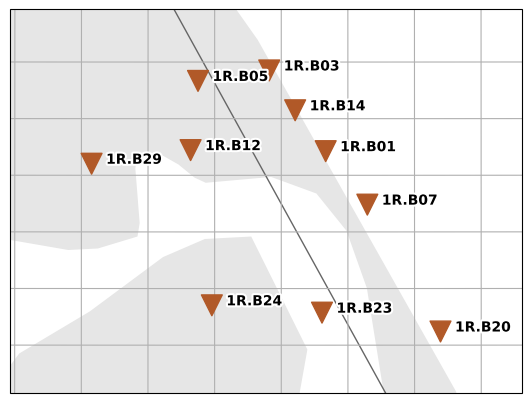

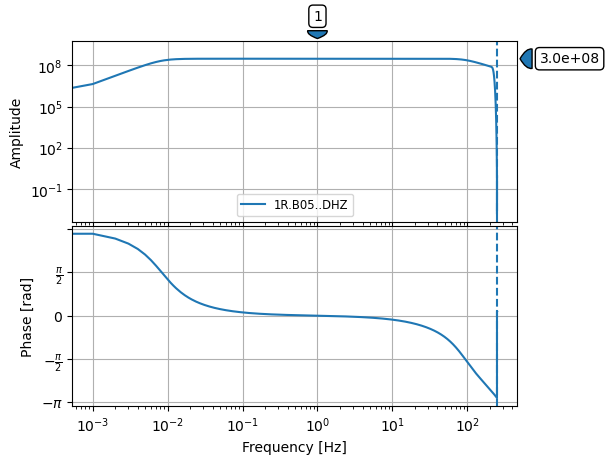


Wrote StationXML: ksc_all10_inventory.xml


In [10]:

import pandas as pd
from obspy import UTCDateTime
from obspy.clients.nrl import NRL
from obspy.core.inventory import Inventory, Network, Station, Channel, Site

NETWORK_CODE = "1R"
NETWORK_DESCRIPTION = "KSC Seismic Network"
START_DATE = UTCDateTime(2026, 1, 7)

CHANNEL_CODES = ["DHZ", "DHN", "DHE"]
LOCATION_CODE = ""
FS = 500
ELEVATION_M = 0.0
DEPTH_M = 0.75

def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def make_channel(chan_code, lat, lon, response=None):
    if chan_code.endswith("Z"):
        azimuth = 0.0
        dip = -90.0
    elif chan_code.endswith("N"):
        azimuth = 0.0
        dip = 0.0
    else:  # E
        azimuth = 90.0
        dip = 0.0

    return Channel(
        code=chan_code,
        location_code=LOCATION_CODE,
        latitude=float(lat),
        longitude=float(lon),
        elevation=ELEVATION_M,
        depth=DEPTH_M,
        azimuth=azimuth,
        dip=dip,
        sample_rate=FS,
        response=response,
    )

def is_usf_station(row):
    seismometer = safe_text(row["Seismometer"]).lower()
    digitizer = safe_text(row["Digitizer"]).lower()
    return ("trillium" in seismometer) or ("centaur" in digitizer)

# Known USF response from the NRL
nrl = NRL()

usf_sensor_keys = [
    "Nanometrics",
    "Trillium Compact 120 (Vault, Posthole, OBS)",
    "754 V/m/s",
]

usf_datalogger_keys = [
    "Nanometrics",
    "Centaur",
    "40 Vpp (1)",
    "Off",
    "Linear phase",
    str(FS),
]

resp_usf = nrl.get_response(
    sensor_keys=usf_sensor_keys,
    datalogger_keys=usf_datalogger_keys,
)

stations_list = []

for _, row in stations.iterrows():
    sta_code = safe_text(row["Site Name"])
    sta_lat = float(row["lat"])
    sta_lon = float(row["lon"])

    if is_usf_station(row):
        response_to_use = resp_usf
        response_label = "USF response"
    else:
        response_to_use = None
        response_label = "channel-only (non-USF station)"

    channels = []
    for chan_code in CHANNEL_CODES:
        ch = make_channel(chan_code, sta_lat, sta_lon, response=response_to_use)
        channels.append(ch)

    sta = Station(
        code=sta_code,
        latitude=sta_lat,
        longitude=sta_lon,
        elevation=ELEVATION_M,
        creation_date=START_DATE,
        site=Site(name=sta_code),
        channels=channels,
    )

    stations_list.append(sta)
    print(f"{sta_code}: {response_label}")

network = Network(
    code=NETWORK_CODE,
    description=NETWORK_DESCRIPTION,
    start_date=START_DATE,
    stations=stations_list,
)

inventory = Inventory(
    networks=[network],
    source="KSC Seismic Network",
)

print()
print(inventory)
print()
print("Number of stations in inventory:", len(inventory.networks[0].stations))
print("Station codes:", [sta.code for sta in inventory.networks[0].stations])

inventory.plot(projection="local", level="channel")
inventory.plot_response(min_freq=0.001, output="VEL", station="B05", channel="DHZ")

out_xml = "ksc_all10_inventory.xml"
inventory.write(out_xml, format="STATIONXML")
print(f"\nWrote StationXML: {out_xml}")
